# Project 7: Stream Analysis — Algorithms for Massive Datasets

Downloading the dataset

In [36]:
import os,glob,zipfile, random, hashlib, matplotlib.pyplot as plt, math, sys

random.seed(42) #will be used later on

try:
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
except ImportError:
    pass  # not on Colab — kaggle will find ~/.kaggle/kaggle.json automatically

ZIP = "new-york-times-articles-comments-2020.zip"

if not os.path.exists("data"):
    !pip install -q kaggle
    if not os.path.exists(ZIP):
        !kaggle datasets download -q -d benjaminawd/new-york-times-articles-comments-2020
    with zipfile.ZipFile(ZIP) as z:
        z.extractall("data")
    print("Dataset downloaded and extracted.")
else:
    print("Dataset already present, skipping.")

for path in sorted(glob.glob("data/**/*", recursive=True)):
    if os.path.isfile(path):
        print(f"{os.path.getsize(path)/1e6:10.1f} MB   {path}")

Dataset already present, skipping.
       7.9 MB   data\nyt-articles-2020.csv
    3066.9 MB   data\nyt-comments-2020.csv
     303.3 MB   data\nyt-comments-part0.csv
     303.5 MB   data\nyt-comments-part1.csv
     302.0 MB   data\nyt-comments-part2.csv
     309.7 MB   data\nyt-comments-part3.csv
     309.0 MB   data\nyt-comments-part4.csv
     309.9 MB   data\nyt-comments-part5.csv
     308.5 MB   data\nyt-comments-part6.csv
     311.6 MB   data\nyt-comments-part7.csv
     310.9 MB   data\nyt-comments-part8.csv
     298.6 MB   data\nyt-comments-part9.csv
       1.9 MB   data\test.csv
       6.0 MB   data\train.csv


In [2]:
import csv

PATH = "data/nyt-comments-2020.csv"

with open(PATH, newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    print(f"{len(header)} columns:\n")
    for col in header:
        print("  ", col)

23 columns:

   commentID
   status
   commentSequence
   userID
   userDisplayName
   userLocation
   userTitle
   commentBody
   createDate
   updateDate
   approveDate
   recommendations
   replyCount
   editorsSelection
   parentID
   parentUserDisplayName
   depth
   commentType
   trusted
   recommendedFlag
   permID
   isAnonymous
   articleID


## Input layer

checking items in each row

In [3]:
PATH = "data/nyt-articles-2020.csv"

with open(PATH, newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    print(f"{len(header)} columns:\n")
    for col in header:
        print("  ", col)

11 columns:

   newsdesk
   section
   subsection
   material
   headline
   abstract
   keywords
   word_count
   pub_date
   n_comments
   uniqueID


In [4]:
# SUBSAMPLE flag

SUBSAMPLE = True
SUBSAMPLE_SIZE = 500000

if SUBSAMPLE:
    limit = SUBSAMPLE_SIZE
else:
    limit = None

Making a reader for the file - the `DictReader` reads lazily - one row at a time on demand. So the whole file is never loaded in memory, the reader grabs one row, yield passes the one line, which means only ever one row is loaded in memory

In [5]:
def comment_stream(path, limit):
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
                if limit is not None and i >= limit:
                    break
                else:
                    yield row

# Algorithms
## Bloom filter

In [40]:
class BloomFilter:
    
    def __init__(self, size, num_hashes):
        self.size = size
        self.num_hashes = num_hashes
        self.bits = bytearray(size)
    
    def _hashes(self, item):
        values = []
        for i in range(self.num_hashes):
            #this makes it so I can get n hash functions from the same one - the hashing doesnt actually change, the item does in a determined way
            combine = f"{i}_{item}"
            h = hash(combine)
            position = abs(h) % self.size
            values.append(position)
        return values

    def add(self, item):
        values = self._hashes(item)
        for i in values:
            self.bits[i] = 1

    def check(self, item):
        present = True
        values = self._hashes(item)
        for i in values:
            if self.bits[i] == 0:
                present = False
        return present

## Flajolet-Martin

In [7]:
from statistics import median
class FlajoletMartin:
    def __init__(self, num_hashes):
        self.num_hashes = num_hashes
        self.max_tails = [0]*num_hashes
    def _tail_length(self, x):
        if x == 0:
            return 0
        tail_length = (x & -x).bit_length() - 1 #bitwise AND isolates lowest bit in binary expression. the bit is included, so -1 to get number of trailing zeros
        return tail_length

    def add(self, item):
        for i in range(self.num_hashes):
            combine = f"{i}_{item}"
            digest = hashlib.md5(combine.encode()).hexdigest()
            h = int(digest, 16)
            tail_length = self._tail_length(h)
            if tail_length > self.max_tails[i]:
                self.max_tails[i] = tail_length

    def estimate(self, group_size):
        estimates = []
        for r in self.max_tails:
            estimates.append(2**r)
        group_medians = []
        for start in range(0, len(estimates), group_size):
            group = estimates[start : start + group_size]
            m = median(group)
            group_medians.append(m) 
        return sum(group_medians)/len(group_medians)

## AMS
### Section lookup table

In [8]:
def load_sections(path):  #path of articles file
    section_dict = {}

    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            key = row['uniqueID']
            value = row['section']
            section_dict[key] = value
        return section_dict

### AMS 

In [9]:
class AMS:
    def __init__(self, num_vars):
        self.num_vars = num_vars
        self.vars_element = [None]*num_vars 
        self.vars_count = [0]*num_vars
        self.t = 0 #number of stream elements seen so far

    def add(self, element):
        self.t += 1
        for j in range(self.num_vars):
            if random.random() < 1/self.t: #selects randomly wether to keep the current counted element or to switch to a new one
                self.vars_element[j] = element
                self.vars_count[j] = 1
            elif element == self.vars_element[j]: #still counting same element, if it is a match:
                self.vars_count[j] += 1
                
    def estimate(self):
        res = []
        for j in range(self.num_vars):
            est = self.t * (2 * self.vars_count[j] - 1)
            res.append(est)
        return sum(res)/len(res)

## Running the algorithms on data stream

In [10]:
bloom = BloomFilter(size = 1000000, num_hashes = 3)
fm = FlajoletMartin(num_hashes = 20)
ams = AMS(num_vars=50)
section_of = load_sections("data/nyt-articles-2020.csv")

for row in comment_stream("data/nyt-comments-2020.csv", limit=limit):
    user = row['userID']
    article = row['articleID']
    section = section_of.get(article, "UNKNOWN")

    bloom.add(article)
    fm.add(user)
    ams.add(section)

In [11]:
print("Bloom — checked article seen:", bloom.check(article))   # last article, should be True
print("FM — estimated distinct users:", fm.estimate(group_size=5))
print("AMS — estimated F2 of sections:", ams.estimate())

Bloom — checked article seen: True
FM — estimated distinct users: 90112.0
AMS — estimated F2 of sections: 59675980000.0


### Ground truths

In [12]:
users_set = set()
section_counts = {}
for row in comment_stream("data/nyt-comments-2020.csv", limit=limit):
    users_set.add(row['userID'])
    section = section_of.get(row['articleID'], "UNKNOWN")
    section_counts[section] = section_counts.get(section, 0) + 1
distinct_users = len(users_set)
true_f2 = sum(c*c for c in section_counts.values()) 
print(distinct_users, true_f2)

91437 62286396546


## Experiments

In [22]:
EXP_LIMIT = 50000
exp_users = set()
for row in comment_stream("data/nyt-comments-2020.csv", limit=EXP_LIMIT):   # EXP_LIMIT, not limit
    exp_users.add(row['userID'])
exp_true_users = len(exp_users)
print("true distinct users in experiment slice:", exp_true_users)

true distinct users in experiment slice: 20108


64 hashes: 1.850009946290034 %
128 hashes: 12.035010940919037 %
256 hashes: 6.942510443604536 %
512 hashes: 4.396260194947285 %
1024 hashes: 4.515615675353094 %
2048 hashes: 0.696240302367217 %


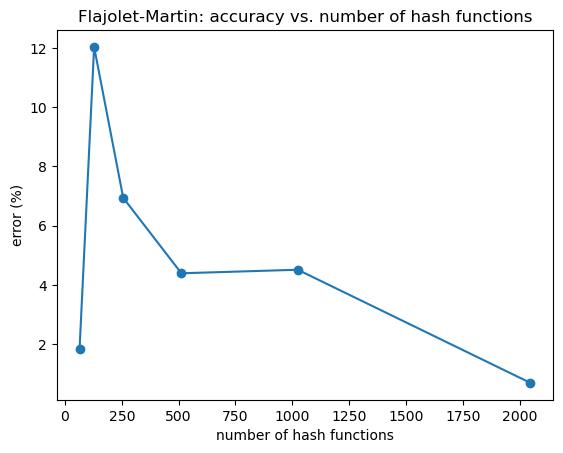

In [23]:
#testing Flajolet-Martin on different numbers of hash functions, to see which will yield the best result
xs = []
ys = []
for h in [64, 128, 256, 512, 1024, 2048]:
    est = run_fm(num_hashes=h, group_size=32, limit=EXP_LIMIT)
    error = abs(est - exp_true_users) / exp_true_users * 100
    xs.append(h)
    ys.append(error)
    print(h, "hashes:", error, "%")

plt.plot(xs, ys, marker='o')
plt.xlabel("number of hash functions")
plt.ylabel("error (%)")
plt.title("Flajolet-Martin: accuracy vs. number of hash functions")
plt.show()

In [24]:
def run_ams(num_vars, limit):
    ams = AMS(num_vars)
    for row in comment_stream("data/nyt-comments-2020.csv", limit=limit):
        section = section_of.get(row['articleID'], "UNKNOWN")
        ams.add(section)
    return ams.estimate()

In [25]:
exp_section_counts = {}

for row in comment_stream("data/nyt-comments-2020.csv", limit=EXP_LIMIT):
    section = section_of.get(row['articleID'], "UNKNOWN")
    exp_section_counts[section] = exp_section_counts.get(section, 0) + 1
exp_true_f2 = sum(c*c for c in exp_section_counts.values())
print("true F2 for experiment slice:", exp_true_f2)

true F2 for experiment slice: 565787146


10 vars: 22.322705790138254 %
25 vars: 16.891056977105663 %
50 vars: 8.629473883452278 %
100 vars: 4.352202091208342 %
200 vars: 3.900422933963226 %
500 vars: 2.51045837651462 %
1000 vars: 1.9925725212569603 %


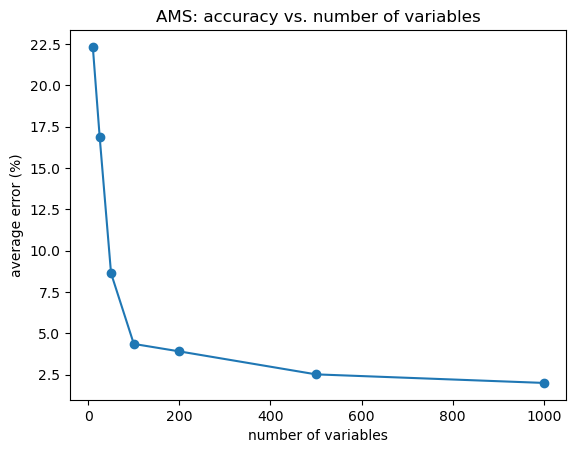

In [26]:
random.seed(42)
trials = 10
xs = []
ys = []
for v in [10, 25, 50, 100, 200, 500, 1000]:
    total_error = 0
    for _ in range(trials):
        est = run_ams(num_vars=v, limit=EXP_LIMIT)
        total_error += abs(est - exp_true_f2) / exp_true_f2 * 100
    avg_error = total_error / trials
    xs.append(v)
    ys.append(avg_error)
    print(v, "vars:", avg_error, "%")   # keep printing too, for the record

plt.plot(xs, ys, marker='o')
plt.xlabel("number of variables")
plt.ylabel("average error (%)")
plt.title("AMS: accuracy vs. number of variables")
plt.show()

In [41]:
print("EXP_LIMIT =", EXP_LIMIT)
print("exp_true_users =", exp_true_users)

# recompute the truth for the EXACT slice run_fm uses, fresh:
check = set()
for row in comment_stream("data/nyt-comments-2020.csv", limit=EXP_LIMIT):
    check.add(row['userID'])
print("actual distinct users in EXP_LIMIT slice =", len(check))

EXP_LIMIT = 50000
exp_true_users = 20108
actual distinct users in EXP_LIMIT slice = 20108


In [42]:
article_ids = set()
for row in comment_stream("data/nyt-comments-2020.csv", limit=None):
    article_ids.add(row['articleID'])

article_ids = list(article_ids)
half = len(article_ids) // 2
members = article_ids[:half]
non_members = article_ids[half:]
print("members:", len(members), " non-members:", len(non_members))

members: 8393  non-members: 8394


In [43]:
import math

def bloom_fp_rate(size, num_hashes, members, non_members):
    bf = BloomFilter(size, num_hashes)
    for m in members:
        bf.add(m)
    false_positives = 0
    for x in non_members:
        if bf.check(x) == True:
            false_positives += 1
    measured = false_positives / len(non_members)
    m_count = len(members)
    theoretical = (1 - math.exp(-num_hashes * m_count / size)) ** num_hashes
    return measured, theoretical

2000 bits:  measured 1.0  theoretical 0.9999897772110492
5000 bits:  measured 0.981177031212771  theoretical 0.9806235283470294
10000 bits:  measured 0.7724565165594472  theoretical 0.7770925702185106
30000 bits:  measured 0.17881820347867525  theoretical 0.1832380177837595
100000 bits:  measured 0.010483678818203479  theoretical 0.011028813478208969
300000 bits:  measured 0.0004765308553728854  theoretical 0.0005217453085881013


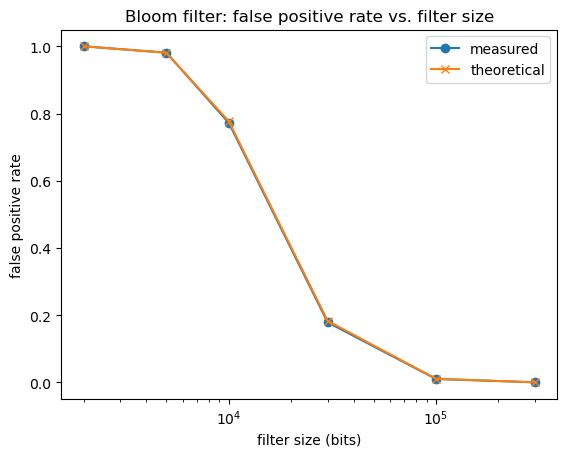

In [44]:
import matplotlib.pyplot as plt

xs, meas, theo = [], [], []
for size in [2000, 5000, 10000, 30000, 100000, 300000]:
    m, t = bloom_fp_rate(size, 3, members, non_members)
    xs.append(size)
    meas.append(m)
    theo.append(t)
    print(size, "bits:  measured", m, " theoretical", t)

plt.plot(xs, meas, marker='o', label='measured')
plt.plot(xs, theo, marker='x', label='theoretical')
plt.xlabel('filter size (bits)')
plt.ylabel('false positive rate')
plt.title('Bloom filter: false positive rate vs. filter size')
plt.legend()
plt.xscale('log')
plt.show()

# Main run - disc streaming

Running all three algorithms at the same time on the full subsample stream of the data, using the efficient hyperparameters found in the experiments section. 
## Results accuracy

In [35]:
fm = FlajoletMartin(num_hashes=256)
ams = AMS(num_vars=200)

# ground truths
users_seen = set()
section_counts = {}

# Single pass over data stream
for row in comment_stream("data/nyt-comments-2020.csv", limit=limit):
    user = row['userID']
    article = row['articleID']
    section = section_of.get(article, "UNKNOWN")

    #  algorithms
    fm.add(user)
    ams.add(section)

    # ground truths
    users_seen.add(user)
    section_counts[section] = section_counts.get(section, 0) + 1

# results: estimate vs. exact, for all three
true_users = len(users_seen)
true_f2 = sum(c*c for c in section_counts.values())

fm_est = fm.estimate(group_size=32)
ams_est = ams.estimate()

print("FM   — distinct users: estimate", fm_est, " exact", true_users,
      " error", abs(fm_est-true_users)/true_users*100, "%")
print("AMS  — F2 of sections: estimate", ams_est, " exact", true_f2,
      " error", abs(ams_est-true_f2)/true_f2*100, "%")

FM   — distinct users: estimate 86016.0  exact 91437  error 5.928672200531514 %
AMS  — F2 of sections: estimate 66846520000.0  exact 62286396546  error 7.321218928810948 %


## Testing memory usage

10000 comments:  FM 2104  AMS 3312  Bloom 1000057  exact set 524504 bytes
50000 comments:  FM 2104  AMS 3312  Bloom 1000057  exact set 2097368 bytes
100000 comments:  FM 2104  AMS 3312  Bloom 1000057  exact set 2097368 bytes
200000 comments:  FM 2104  AMS 3312  Bloom 1000057  exact set 2097368 bytes
500000 comments:  FM 2104  AMS 3312  Bloom 1000057  exact set 4194520 bytes


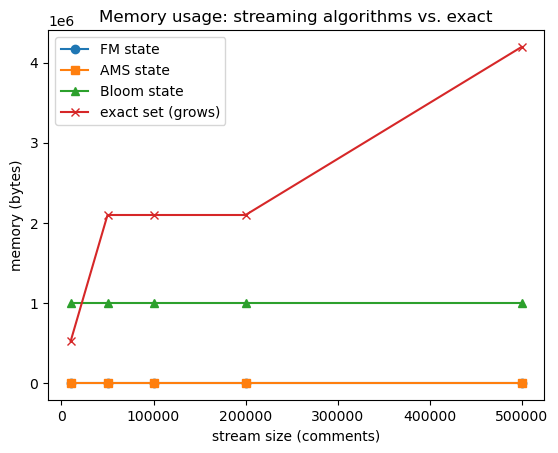

In [45]:
import sys

sizes = [10000, 50000, 100000, 200000, 500000]
fm_memory = []
ams_memory = []
bloom_memory = []
set_memory = []

for n in sizes:
    fm = FlajoletMartin(num_hashes=256)
    ams = AMS(num_vars=200)
    bloom = BloomFilter(size=1000000, num_hashes=3)
    users = set()

    for row in comment_stream("data/nyt-comments-2020.csv", limit=n):
        user = row['userID']
        article = row['articleID']
        section = section_of.get(article, "UNKNOWN")

        fm.add(user)
        ams.add(section)
        bloom.add(article)
        users.add(user)

    fm_memory.append(sys.getsizeof(fm.max_tails))
    ams_memory.append(sys.getsizeof(ams.vars_element) + sys.getsizeof(ams.vars_count))
    bloom_memory.append(sys.getsizeof(bloom.bits))
    set_memory.append(sys.getsizeof(users))

    print(n, "comments:  FM", fm_memory[-1],
          " AMS", ams_memory[-1],
          " Bloom", bloom_memory[-1],
          " exact set", set_memory[-1], "bytes")

plt.plot(sizes, fm_memory, marker='o', label='FM state')
plt.plot(sizes, ams_memory, marker='s', label='AMS state')
plt.plot(sizes, bloom_memory, marker='^', label='Bloom state')
plt.plot(sizes, set_memory, marker='x', label='exact set (grows)')
plt.xlabel('stream size (comments)')
plt.ylabel('memory (bytes)')
plt.title('Memory usage: streaming algorithms vs. exact')
plt.legend()
plt.show()